In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [12]:
df = pd.read_excel("EastWestAirlines.xlsx")

df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [13]:
type(df)

pandas.core.frame.DataFrame

In [3]:
df.shape

(26, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [5]:
df.describe()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,18,13,6,13,18
unique,18,3,3,3,18
top,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,Description
freq,1,9,3,9,1


In [6]:
df.isnull().sum()

East-West Airlines is trying to learn more about its customers.  Key issues are their     8
Unnamed: 1                                                                               13
Unnamed: 2                                                                               20
Unnamed: 3                                                                               13
Unnamed: 4                                                                                8
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [14]:
df.columns

Index(['East-West Airlines is trying to learn more about its customers.  Key issues are their',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
      dtype='object')

In [17]:
print(df.head(10))

  East-West Airlines is trying to learn more about its customers.  Key issues are their  \
0  flying patterns, earning and use of frequent f...                                      
1  card.  The task is to identify customer segmen...                                      
2                                                NaN                                      
3                                                NaN                                      
4  Source: Based upon real business data; company...                                      
5             (c) 2016 Galit Shmueli and Peter Bruce                                      
6                                                NaN                                      
7                                                NaN                                      
8                                         Field Name                                      
9                                                ID#                                      

In [18]:
xls = pd.ExcelFile("EastWestAirlines.xlsx")
print(xls.sheet_names)

['Description', 'data']


In [19]:
import pandas as pd

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name='data')

In [20]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [21]:
print(df.columns)

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')


In [22]:
if 'ID#' in df.columns:
    df = df.drop('ID#', axis=1)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [24]:
print(scaled_data.shape)

(3999, 11)


In [25]:
df.head()
print(df.columns)

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

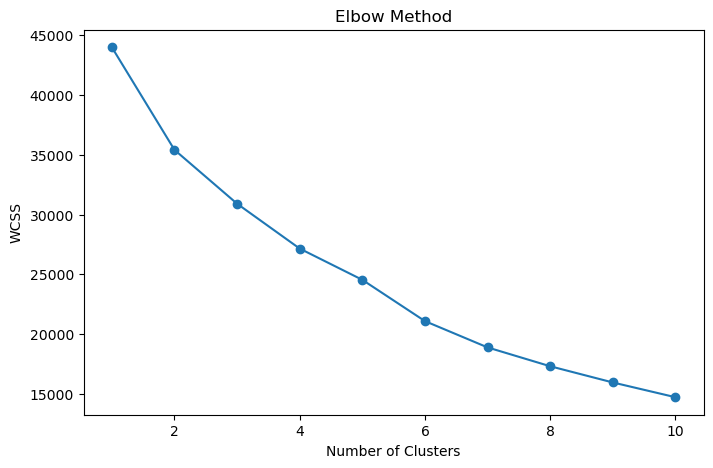

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

In [30]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    kmeans_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.30918774313627845


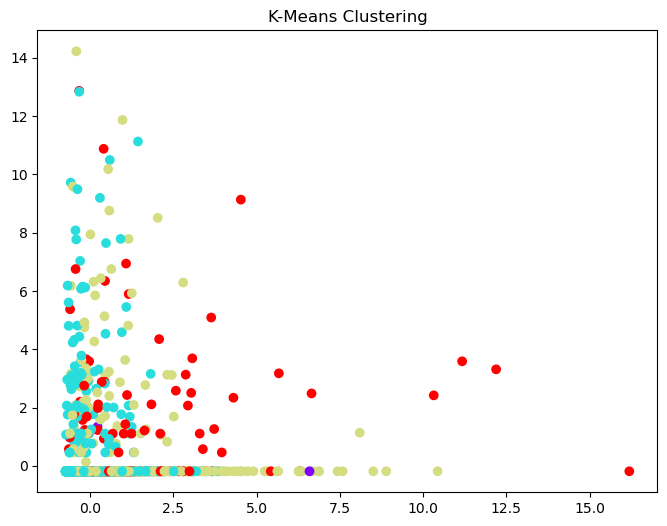

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=kmeans_labels,
    cmap='rainbow'
)

plt.title("K-Means Clustering")
plt.show()

In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(scaled_data)

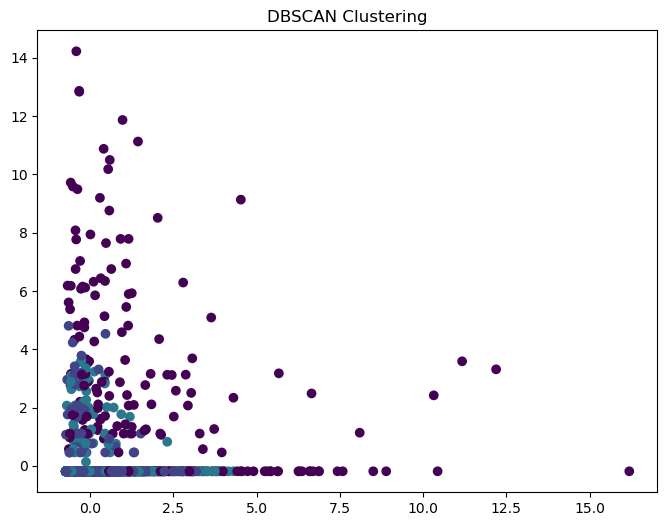

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=dbscan_labels,
    cmap='viridis'
)

plt.title("DBSCAN Clustering")
plt.show()

In [34]:
if len(set(dbscan_labels)) > 1:
    score_db = silhouette_score(
        scaled_data,
        dbscan_labels
    )
    print("DBSCAN Silhouette Score:", score_db)
else:
    print("Only one cluster found")

DBSCAN Silhouette Score: 0.253747538041624


In [35]:
df['KMeans_Cluster'] = kmeans_labels

df.groupby('KMeans_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
1,43793.917814,97.436886,1.221785,1.019269,1.000393,4700.690916,6.918993,198.621707,0.618168,3691.559969,0.201337
2,116817.336214,154.756481,3.701493,1.002357,1.001571,39216.199529,18.759623,334.355852,0.997643,4893.491752,0.648075
3,191573.726190,775.863095,2.172619,1.035714,1.000000,31412.160714,26.779762,5365.672619,15.636905,4665.827381,0.809524


Dataset Shape: (3999, 12)

First 5 Rows
   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  

Dataset Informat

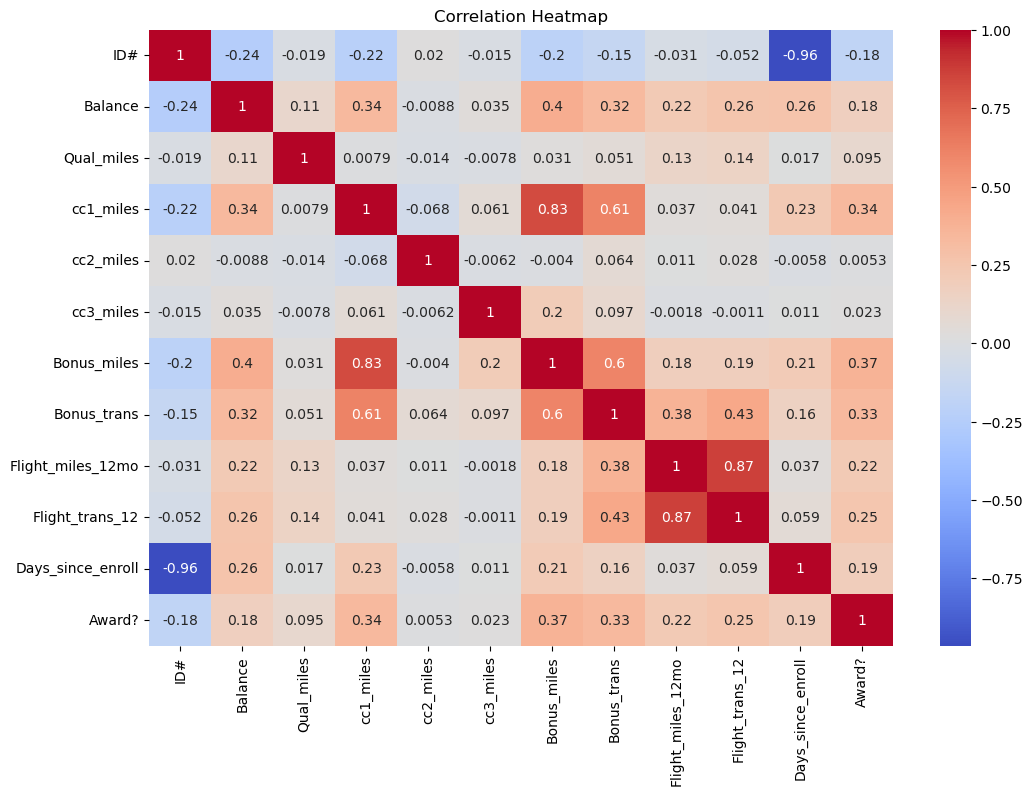

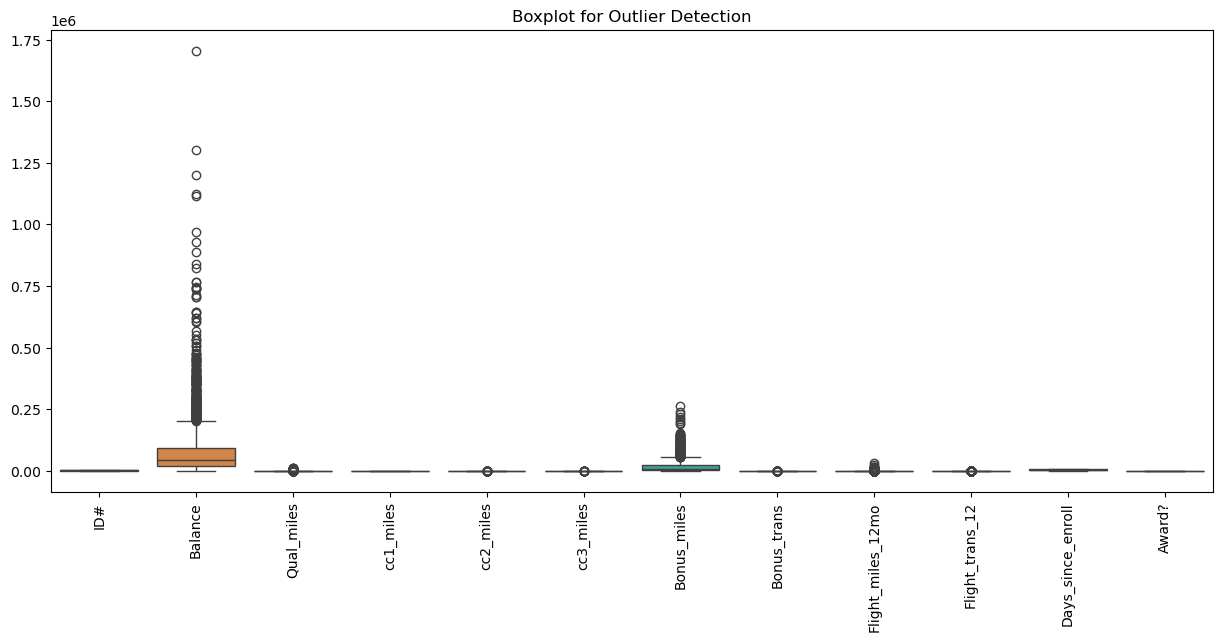


Scaled Data Shape:
(3999, 12)


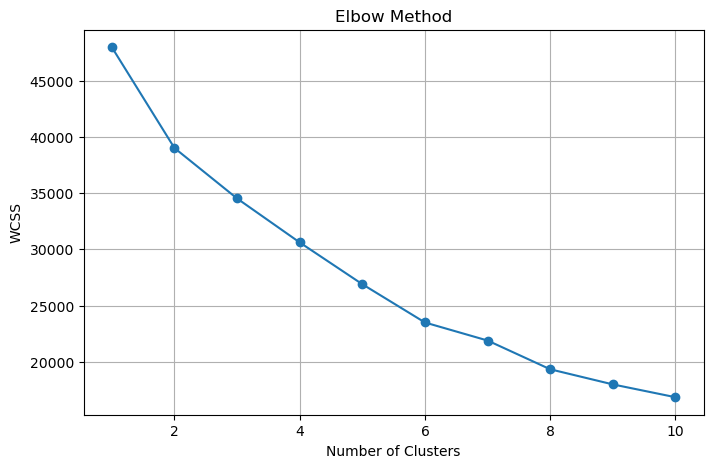

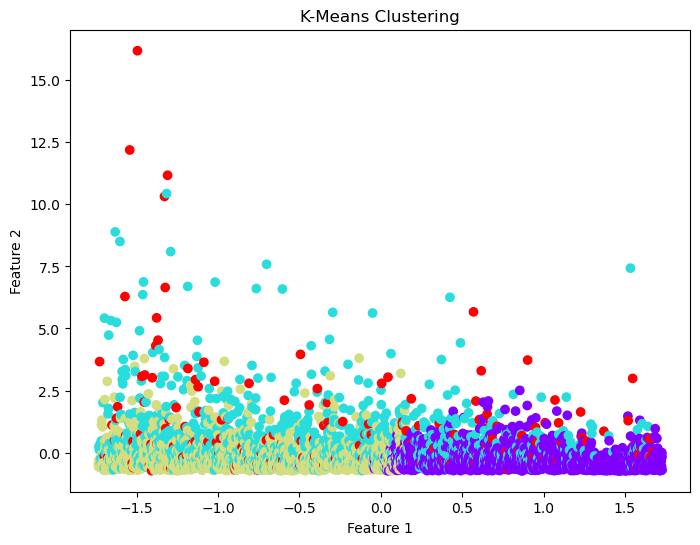


K-Means Silhouette Score:
0.22808887010836637

K-Means Cluster Analysis
                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               3133.055231   39898.197531  106.287199   1.388564   1.016894   
1               1532.492552  127734.216485  160.202582   3.959285   1.001986   
2               1094.120278   56985.831149   96.370085   1.363917   1.018504   
3               1751.262821  194803.871795  810.397436   2.198718   1.038462   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.000000   6271.906433     7.831709         201.923977   
1                1.047666  45887.323734    19.507448         371.256207   
2                1.000771   5886.720894     7.996916         227.814187   
3                1.000000  32475.410256    27.737179        5510.717949

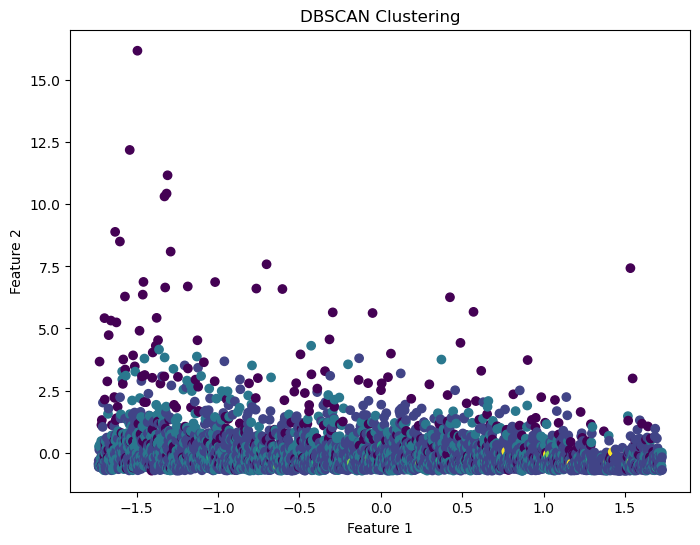


DBSCAN Silhouette Score:
0.1895328629344176

DBSCAN Cluster Analysis
                        ID#        Balance   Qual_miles  cc1_miles  cc2_miles  \
DBSCAN_Cluster                                                                  
-1              1693.559659  204171.247159  1287.965909   2.698864   1.076705   
 0              2182.146423   56194.498752    29.129368   1.683444   1.000000   
 1              1763.081414   70929.623355    43.522204   2.632401   1.000000   
 2              2453.933333   38556.733333     0.000000   1.000000   2.000000   
 3              2671.625000   36524.250000     0.000000   1.000000   3.000000   
 4              3290.250000   62722.000000     0.000000   3.750000   1.000000   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
DBSCAN_Cluster                                                            
-1               1.139205  43413.386364    24.380682        2843.946023   
 0               1.000000   9550.760399     8.693428    

In [36]:
# ==========================================
# CLUSTERING ANALYSIS - EASTWEST AIRLINES
# K-MEANS AND DBSCAN
# ==========================================

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name='data')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
print(df.head())


# ==========================================
# 3. DATA INFORMATION
# ==========================================

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


# ==========================================
# 4. EXPLORATORY DATA ANALYSIS
# ==========================================

# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Boxplot

plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()


# ==========================================
# 5. DATA SCALING
# ==========================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print("\nScaled Data Shape:")
print(scaled_data.shape)


# ==========================================
# 6. ELBOW METHOD
# ==========================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)

plt.show()


# ==========================================
# 7. K-MEANS CLUSTERING
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels


# ==========================================
# 8. K-MEANS VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=kmeans_labels,
    cmap='rainbow'
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


# ==========================================
# 9. K-MEANS SILHOUETTE SCORE
# ==========================================

kmeans_score = silhouette_score(
    scaled_data,
    kmeans_labels
)

print("\nK-Means Silhouette Score:")
print(kmeans_score)


# ==========================================
# 10. K-MEANS CLUSTER ANALYSIS
# ==========================================

print("\nK-Means Cluster Analysis")

print(
    df.groupby('KMeans_Cluster').mean()
)


# ==========================================
# 11. DBSCAN CLUSTERING
# ==========================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    scaled_data
)

df['DBSCAN_Cluster'] = dbscan_labels


# ==========================================
# 12. DBSCAN VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=dbscan_labels,
    cmap='viridis'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


# ==========================================
# 13. DBSCAN SILHOUETTE SCORE
# ==========================================

if len(set(dbscan_labels)) > 1:

    dbscan_score = silhouette_score(
        scaled_data,
        dbscan_labels
    )

    print("\nDBSCAN Silhouette Score:")
    print(dbscan_score)

else:

    print("\nOnly One Cluster Found")


# ==========================================
# 14. DBSCAN CLUSTER ANALYSIS
# ==========================================

print("\nDBSCAN Cluster Analysis")

print(
    df.groupby('DBSCAN_Cluster').mean()
)


# ==========================================
# 15. FINAL DATASET
# ==========================================

print("\nFinal Dataset with Cluster Labels")

print(df.head())


# ==========================================
# 16. INSIGHTS
# ==========================================

print("\n----- INSIGHTS -----")

print("""
1. The Elbow Method suggests 4 clusters.
2. K-Means grouped customers based on travel activity,
   bonus miles and enrollment behaviour.
3. DBSCAN identified dense groups and outliers.
4. Customers in different clusters show different
   airline usage patterns.
5. Clustering can help the airline target customers
   with personalized marketing strategies.
""")